# The co-training dial — an aleph adapter on a 4-block MNIST trunk

**The question.** Snap an aleph adapter onto a miniature 4-block linear
MNIST classifier and train both at once. What happens?

That is not one run. The campaign record already answers the two extremes,
and they disagree:

| regime | finding | evidence |
|---|---|---|
| **co-trained** | the address-bottleneck prior **pays** | exp012: beat an unrestricted head 7/7 across seeds and budgets; held at d=384 |
| **frozen substrate** | it **costs** | exp013 Track A: param-matched MLP wins, aleph tax ~ +0.09 CE, 2 seeds |

Both are canon. **Nothing between them has ever been measured.** The plan
that would have measured it was ranked first in the standing queue and got
displaced before it ran.

So we turn a dial instead of firing one run:

```
trainable trunk blocks:   0        1        2        4
                       frozen  --------------->  full co-training
                    (exp013 pole)             (exp012 pole)
```

Where the curve crosses zero — if it does — is the boundary law.

**Preregistered forks** (write the verdict from whichever fires; all are
canon-grade either way) are listed in
[`experiments/README.md`](../README.md). Read them before you look at a
number, not after.

Runtime: ~3 min quick pass, ~25 min full sweep. Runs on CPU; a T4 is plenty.

## 0 · Setup — one cell, nothing preinstalled

This is the whole dependency story. In a **fresh Colab runtime** it clones
the `experimental` branch (where `experiments/` lives — it is **not** on
`main`), puts `src/` and `experiments/` on `sys.path`, and imports.

No editable `pip install` and no build step: `amoe`'s only hard dependency
is `torch`, which Colab already ships, so pointing `sys.path` at the
checkout is enough. `torchvision` (also preinstalled on Colab) is fetched
only if genuinely missing. If you already have a local `experimental`
checkout, it uses that and clones nothing.

Idempotent: safe to re-run, safe to paste into a fresh runtime.

In [1]:
import os, sys, subprocess

REPO   = 'https://github.com/AbstractEyes/amoe-lora'
BRANCH = 'experimental'          # experiments/ lives here, not on main
IN_COLAB = 'google.colab' in sys.modules

def find_root(start='.'):
    """Walk up for a checkout that actually has the experiment code.
    Requires experiments/ so a bare `main` checkout won't match. No
    __file__ reliance — this cell must survive being pasted anywhere."""
    p = os.path.abspath(start)
    while p != os.path.dirname(p):
        if (os.path.isfile(os.path.join(p, 'pyproject.toml')) and
                os.path.isdir(os.path.join(p, 'experiments', 'aleph_mnist'))):
            return p
        p = os.path.dirname(p)
    return None

ROOT = find_root()
if ROOT is None:                 # fresh runtime: clone the branch
    ROOT = '/content/amoe-lora'
    if not os.path.isdir(os.path.join(ROOT, 'experiments', 'aleph_mnist')):
        subprocess.run(['git', 'clone', '--depth', '1', '--branch', BRANCH,
                        REPO, ROOT], check=True)

# amoe (src/) and the experiment package (experiments/) go straight on
# sys.path — no build, no editable install to fail on.
for p in (os.path.join(ROOT, 'src'), os.path.join(ROOT, 'experiments')):
    if p not in sys.path:
        sys.path.insert(0, p)
os.chdir(ROOT)

try:                            # the only dep beyond torch; Colab has both
    import torchvision          # noqa: F401
except ImportError:
    subprocess.run([sys.executable, '-m', 'pip', '-q', 'install',
                    'torchvision'], check=True)

assert os.path.isdir(os.path.join(ROOT, 'experiments', 'aleph_mnist')), \
    f'experiment code not found under {ROOT} — is the {BRANCH} branch pushed?'
print(f'root: {ROOT}\nbranch: {BRANCH}  (in_colab={IN_COLAB})\n'
      f'amoe on path: {os.path.join(ROOT, "src")}')

root: /content/amoe-lora
branch: experimental  (in_colab=True)
amoe on path: /content/amoe-lora/src


In [2]:
import torch
import amoe
from amoe import laws
from aleph_mnist import (RunConfig, build_bed, build_trunk, build_heads,
                         pretrain, run, sweep, save_anchor)
from aleph_mnist import probes, plots, vitals
from aleph_mnist.heads import set_adapters

laws.pin_precision()          # fp32, TF32 off — law 5
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'torch {torch.__version__} · device {DEVICE} · amoe {amoe.__version__ if hasattr(amoe, "__version__") else "0.2.2"}')
print(f'binding constant {vitals.BINDING} rad · gate band {vitals.GATE_BAND}'
      f' · escape threshold {laws.BLEND_ESCAPE_RATIO}')

torch 2.11.0+cu128 · device cuda · amoe 0.2.2
binding constant 0.29154 rad · gate band (0.012, 0.03) · escape threshold 1.5


## 1 · The bed

**The starvation is the instrument.** Full MNIST on a 4-block MLP
saturates near 98% and every arm difference disappears into seed noise.
The campaign has been burned by exactly this — a four-arm codebook sweep
on BERT reconstruction found the addressing wasn't load-bearing at all,
because the task was too easy and the model routed around it. The ruling
that came out of it governs this bed: *no champion if it isn't actually
using the alephs.*

So: `d=64`, 4096 class-balanced rows, real headroom left in the task.
Flip `QUICK` off for the full preregistered sweep.

In [3]:
QUICK = True    # False = the full preregistered sweep (2 seeds, 1500 steps)

CFG = RunConfig(
    d=64, n_blocks=4, tokens=1,
    dataset='mnist', train_n=4096, batch=128,
    steps=400 if QUICK else 1500,
    pretrain_steps=600 if QUICK else 1500,
    lr_head=1e-3, lr_trunk=1e-4,
    probe_every=100 if QUICK else 250,
    log_every=200 if QUICK else 500,
    device=DEVICE,
)
SEEDS = (0,) if QUICK else (0, 1)

bed = build_bed(CFG.dataset, CFG.train_n, seed=CFG.seed).to(DEVICE)
print(f'{bed.name}: train {tuple(bed.xtr.shape)} · test {tuple(bed.xte.shape)}')
print('class balance:', torch.bincount(bed.ytr.cpu()).tolist())
print('neutral sets:', {k: tuple(v.shape) for k, v in bed.neutral.items()})

# the hard-zero law: no input float may be a dead zero
print(f'\nbackground pixel value after normalization: {bed.xtr.min():.4f}'
      f'  (exact zeros in batch: {int((bed.xtr == 0).sum())})')

100%|██████████| 9.91M/9.91M [00:00<00:00, 56.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.64MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 13.6MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 31.2MB/s]
100%|██████████| 26.4M/26.4M [00:01<00:00, 17.5MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 318kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.90MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 46.8MB/s]


mnist-n4090: train (4090, 784) · test (10000, 784)
class balance: [409, 409, 409, 409, 409, 409, 409, 409, 409, 409]
neutral sets: {'permuted': (1024, 784), 'noise': (1024, 784), 'fashion': (1024, 784)}

background pixel value after normalization: -0.4242  (exact zeros in batch: 0)


## 2 · Before training: is the contract intact on a vision trunk?

`amoe.runtime.attach._probe` fingerprints a model by calling
`model(input_ids=...)` with an integer tensor — it is written for causal
LMs. `TinyTrunk` accepts `input_ids` and maps it *deterministically* to a
float input rather than forking `attach()`, which makes the bit-exact
guarantee genuinely testable here.

Two things must hold before any result is worth reading:

1. **Toggle law** — adapters off must equal the base model bit-exactly.
2. **Inertness at attach** — a fresh anchor has a zero-init output head, so
   it should be (near) inert. The campaign documents that the LayerNorm/bias
   path leaks anyway. A 784-in/10-out trunk has no vocabulary to hide that
   leak in, so we can put an exact number on it.

In [4]:
t = build_trunk(CFG.d, CFG.n_blocks, CFG.tokens, seed=0).to(DEVICE)
before = probes.evaluate(t, bed.xte, bed.yte)
heads, sites, wrappers = build_heads(t, mode='soft', seed=0)

set_adapters(wrappers, False)
off = probes.evaluate(t, bed.xte, bed.yte)
set_adapters(wrappers, True)

print(f'base            ce {before["ce"]:.10f}')
print(f'adapters OFF    ce {off["ce"]:.10f}')
print(f'TOGGLE LAW      {"HOLDS (bit-exact)" if off["ce"] == before["ce"] else "VIOLATED"}')

leak = probes.inertness(t, wrappers, bed.xte[:512])
print(f'\nzero-init leak  max|dlogit| {leak["max_abs_dlogit"]:.6f}'
      f' · mean {leak["mean_abs_dlogit"]:.6f}'
      f' · argmax flips {leak["argmax_flip_frac"]:.4f}')
print('  (law 3 wants ~0; anything above is the documented bias-path leak)')

print('\nparameter census')
print(f'  trunk   {sum(p.numel() for p in t.parameters()) - sum(p.numel() for h in heads for p in h.parameters()):>8,}')
print(f'  adapter {sum(p.numel() for h in heads for p in h.parameters()):>8,}  ({len(heads)} blocks)')

base            ce 2.4442270264
adapters OFF    ce 2.4442270264
TOGGLE LAW      HOLDS (bit-exact)

zero-init leak  max|dlogit| 0.012180 · mean 0.003594 · argmax flips 0.0117
  (law 3 wants ~0; anything above is the documented bias-path leak)

parameter census
  trunk    117,834
  adapter  110,940  (4 blocks)


### The arms are parameter-identical — verify, don't assume

A delta between arms is only attributable to the *read* if every other
thing is equal. `none` keeps the codebook parameter so counts match, but
nothing reads it — so it must receive exactly zero gradient, and its
measured drift must be exactly `0.000000`.

In [5]:
for mode in ('soft', 'sign', 'none'):
    tt = build_trunk(CFG.d, CFG.n_blocks, CFG.tokens, seed=0).to(DEVICE)
    hh, _, ww = build_heads(tt, mode=mode, seed=0)
    n = sum(p.numel() for h in hh for p in h.parameters())
    logits = tt(bed.xtr[:64]).logits
    torch.nn.functional.cross_entropy(logits, bed.ytr[:64]).backward()
    g = vitals.grad_norm_spread({'codebook': [h.addr.codebook for h in hh]})
    print(f'{mode:6} params {n:>8,} · codebook grad-norm {g["norms"]["codebook"]:.3e}')
print('\n`none` must read 0.000e+00 — that is the control being airtight.')

soft   params  110,940 · codebook grad-norm 0.000e+00
sign   params  110,940 · codebook grad-norm 0.000e+00
none   params  110,940 · codebook grad-norm 0.000e+00

`none` must read 0.000e+00 — that is the control being airtight.


## 3 · Phase 0 + one cell, verbose

**Phase 0 is not optional.** "Frozen" has to mean frozen-*pretrained*, or
the dial's left pole is a random-feature bed and nothing transfers to
exp013's finding. One shared trunk checkpoint per seed; it is also the
baseline curve.

Then one cell at full co-training, watching the vitals move.

In [6]:
BASE = pretrain(RunConfig(**{**CFG.__dict__, 'seed': 0}), bed)

[pretrain s0] step 1 loss=2.5226
[pretrain s0] step 200 loss=0.0594
[pretrain s0] step 400 loss=0.0202
[pretrain s0] step 600 loss=0.0040
[pretrain s0] base ce=0.2708 acc=0.9357


In [7]:
import dataclasses
row = run(dataclasses.replace(CFG, mode='soft', trainable_blocks=4), bed, BASE)

print(f'\n{"step":>6} {"ce":>8} {"acc":>7} {"gate":>8} {"drift":>8}'
      f' {"|dh|/|h|":>9} {"g_trunk":>10} {"g_adapt":>10}')
for s in row['traj']:
    dr = sum(s['delta_ratio']) / len(s['delta_ratio'])
    gn = s['grad']['norms']
    print(f'{s["step"]:>6} {s["ce"]:>8.4f} {s["acc"]:>7.4f}'
          f' {s["gate_mean"]:>8.5f} {s["drift_mean"]:>8.5f} {dr:>9.5f}'
          f' {gn.get("trunk", 0):>10.2e} {gn.get("adapter", 0):>10.2e}')

v = row['vitals']
print(f'\ngate mean {v["gate"]["mean"]:.5f} · in 0.012-0.03 band: {v["gate"]["in_band"]}'
      f'   (started at sigmoid(-3) = 0.04743, ABOVE the band)')
print(f'drift mean {v["drift_mean"]:.5f} rad · binding constant {v["binding_target"]}')
print(f'CM CV per block {v["cv"]}  (D=4 sits ~0.99 by design — logged, never gated)')
print(f'\nescape ratios (<= {laws.BLEND_ESCAPE_RATIO} = blend-regime escape): {row["escape"]["ratio"]}')
print(f'sign codes: {row["sign_codes"]["organism_unique"]} unique organism paths'
      f' over {row["sign_codes"]["n_samples"]} samples')
print(f'toggle damage: acc {row["toggle"]["damage_acc"]:+.4f}'
      f' · ce {row["toggle"]["damage_ce"]:+.4f}')

[soft/dial4/s0] step 1 loss=0.0046
[soft/dial4/s0] step 200 loss=0.0014
[soft/dial4/s0] step 400 loss=0.0007

  step       ce     acc     gate    drift  |dh|/|h|    g_trunk    g_adapt
     1   0.2656  0.9372  0.04740  0.00000   0.00145   2.05e-01   5.02e-03
   100   0.2172  0.9467  0.04711  0.02294   0.00758   2.99e-01   6.49e-03
   200   0.2208  0.9502  0.04784  0.02493   0.01066   1.82e-02   4.42e-04
   300   0.2318  0.9493  0.04905  0.02716   0.01497   6.72e-02   1.87e-03
   400   0.2408  0.9495  0.05072  0.03133   0.02096   4.59e-03   1.45e-04

gate mean 0.05072 · in 0.012-0.03 band: False   (started at sigmoid(-3) = 0.04743, ABOVE the band)
drift mean 0.03133 rad · binding constant 0.29154
CM CV per block [0.9501, 0.9685, 0.8909, 0.8594]  (D=4 sits ~0.99 by design — logged, never gated)

escape ratios (<= 1.5 = blend-regime escape): {'permuted': 0.593, 'noise': 0.643, 'fashion': 0.832}
sign codes: 1024 unique organism paths over 1024 samples
toggle damage: acc +0.0005 · ce -0.0116

Read the last two lines carefully.

**Toggle damage** is the co-training tax on *detachability*. The toggle law
guarantees the mechanism is bit-exact; it guarantees nothing about what the
trunk has come to depend on. A large positive damage means the artifact is
no longer an adapter — it is half the model, and shipping it as a
detachable anchor would be a lie.

**Escape ratio** is the single-anchor analogue of the P5d blend-escape
gauge. `amoe.diagnostics.diagnose` reads amplitude off the *dispatch*,
which only exists with multiple anchors; with one anchor the honest
equivalent is the residual delta ratio measured on real digits vs
structureless input with identical pixel statistics.

## 4 · The dial

`arms x dial x seeds`, every cell from the same phase-0 checkpoint, one
JSON row per cell appended to `experiments/results/ledger.jsonl`.
The ledger is the evidence; the figures are derived from it and nothing is
ever hand-transcribed.

The `scratch` rows at the end answer the question in its literal form —
adapter snapped onto a *fresh* trunk, both moving from step 0.

In [8]:
rows = sweep(seeds=SEEDS, base=CFG, bed=bed, bases={0: BASE})
print(f'\n{len(rows)} cells in the ledger')

[soft/dial0/s0] step 1 loss=0.0046
[soft/dial0/s0] step 200 loss=0.0024
[soft/dial0/s0] step 400 loss=0.0016
  -> soft/dial0/s0: ce=0.2284 acc=0.9495 dCE=+0.0424
[sign/dial0/s0] step 1 loss=0.0046
[sign/dial0/s0] step 200 loss=0.0024
[sign/dial0/s0] step 400 loss=0.0017
  -> sign/dial0/s0: ce=0.2288 acc=0.9484 dCE=+0.0420
[none/dial0/s0] step 1 loss=0.0046
[none/dial0/s0] step 200 loss=0.0024
[none/dial0/s0] step 400 loss=0.0016
  -> none/dial0/s0: ce=0.2285 acc=0.9486 dCE=+0.0423
[soft/dial1/s0] step 1 loss=0.0046
[soft/dial1/s0] step 200 loss=0.0015
[soft/dial1/s0] step 400 loss=0.0008
  -> soft/dial1/s0: ce=0.2375 acc=0.9510 dCE=+0.0333
[sign/dial1/s0] step 1 loss=0.0046
[sign/dial1/s0] step 200 loss=0.0015
[sign/dial1/s0] step 400 loss=0.0008
  -> sign/dial1/s0: ce=0.2358 acc=0.9508 dCE=+0.0350
[none/dial1/s0] step 1 loss=0.0046
[none/dial1/s0] step 200 loss=0.0015
[none/dial1/s0] step 400 loss=0.0008
  -> none/dial1/s0: ce=0.2380 acc=0.9511 dCE=+0.0328
[off/dial1/s0] step 1 loss=0

In [9]:
print(plots.verdict_table(rows))

cell                              ce     acc      dCE    gate   drift  tog_acc    esc   codes
---------------------------------------------------------------------------------------------
soft/dial0/s0                 0.2284  0.9495  +0.0424  0.0557  0.0512   0.0138   0.62    1024
sign/dial0/s0                 0.2288  0.9484  +0.0420  0.0558  0.0508   0.0127   0.62    1024
none/dial0/s0                 0.2285  0.9486  +0.0423  0.0557  0.0000   0.0129   0.63    1024
soft/dial1/s0                 0.2375  0.9510  +0.0333  0.0519  0.0373   0.0033   0.57    1024
sign/dial1/s0                 0.2358  0.9508  +0.0350  0.0523  0.0385   0.0032   0.57    1024
none/dial1/s0                 0.2380  0.9511  +0.0328  0.0518  0.0000   0.0028   0.59    1024
off/dial1/s0                  0.2270  0.9499  +0.0438     nan     nan      nan    nan      -1
soft/dial2/s0                 0.2388  0.9503  +0.0320  0.0512  0.0362   0.0017   0.58    1024
sign/dial2/s0                 0.2372  0.9504  +0.0336  0.051

## 5 · Figures

Six panels, one question each. The top-left panel is the result: where
`Δ(arm − control)` crosses zero is the boundary.

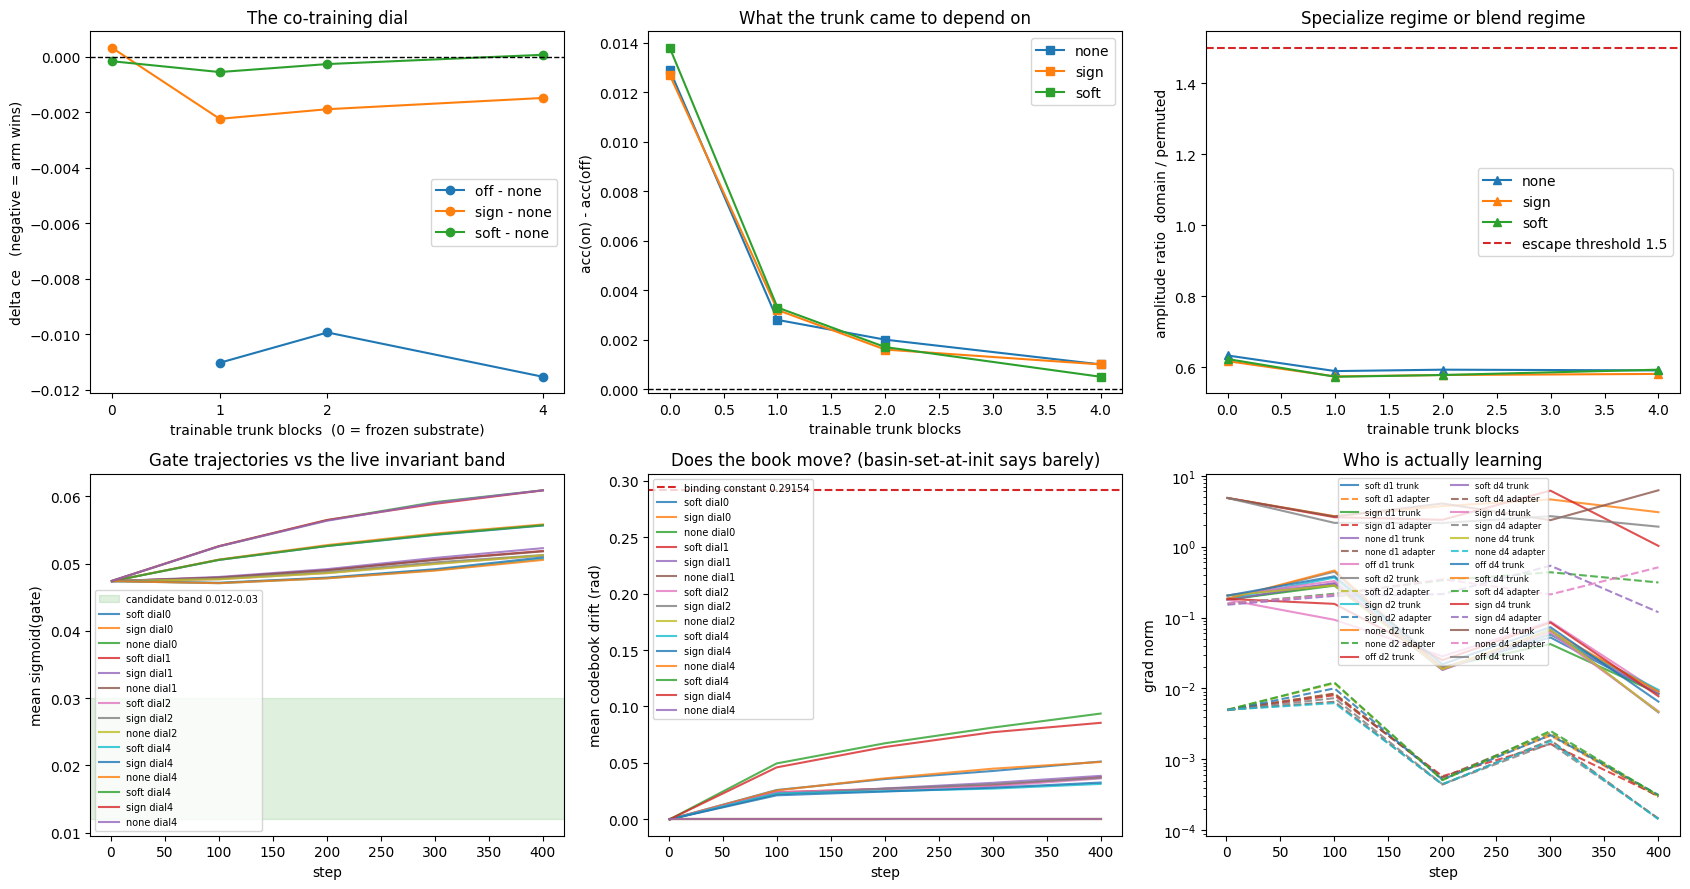

In [10]:
%matplotlib inline
fig = plots.figure_set(rows, path='experiments/results/dial.png')

## 6 · Resolving the preregistered forks

Fill this in from the numbers above — **before** reaching for an
explanation of them.

| # | fork | fires if | verdict |
|---|---|---|---|
| 1 | boundary law lands | Δ(soft−none) crosses zero on the dial | |
| 2 | exp012 is scope-limited | no crossing, aleph trails everywhere | |
| 3 | advantage is placement-specific | no crossing, aleph leads everywhere | |
| 4 | sign/soft ordering flips | sign ≥ soft frozen, soft ≥ sign full | |
| 5 | detachability tax | toggle damage grows with the dial | |

Secondary readouts worth recording either way:

- **gate band** — a 7th architecture for the 0.012–0.03 live invariant
  candidate, on a task geometry unlike the other six. There is a standing
  open question asking whether that band is a delta-window prior or a
  property of task geometry; this bed can speak to it.
- **drift** — basin-set-at-init predicts the book barely moves. Does it?
- **sign-code counts** — differentiation must be *structural*;
  gradient-learned alphabets have collapsed 1,594 → 116 unique paths
  before. If co-training collapses the codes here, it is the same disease
  at 1/1000 the cost.

In [11]:
# quick fork-1 read: the crossing, per dial position
from collections import defaultdict
by = defaultdict(dict)
for r in rows:
    c = r['config']
    if c.get('tag'):
        continue
    by[(c['trainable_blocks'], c['seed'])][c['mode']] = r['final']['ce']
print(f'{"dial":>5} {"soft-none":>12} {"sign-none":>12} {"soft-sign":>12}')
for n in sorted({k[0] for k in by}):
    cells_n = [v for (nn, _), v in by.items() if nn == n]
    def d(a, b):
        xs = [v[a] - v[b] for v in cells_n if a in v and b in v]
        return sum(xs) / len(xs) if xs else float('nan')
    print(f'{n:>5} {d("soft", "none"):>+12.5f} {d("sign", "none"):>+12.5f}'
          f' {d("soft", "sign"):>+12.5f}')
print('\nnegative = the arm beats the control. A SIGN CHANGE down this'
      '\ncolumn is the boundary the campaign never measured.')

 dial    soft-none    sign-none    soft-sign
    0     -0.00016     +0.00033     -0.00048
    1     -0.00055     -0.00223     +0.00169
    2     -0.00026     -0.00189     +0.00163
    4     +0.00007     -0.00148     +0.00156

negative = the arm beats the control. A SIGN CHANGE down this
column is the boundary the campaign never measured.


## 7 · The artifact round-trips through the public API

A result that can't be shipped isn't finished. This saves the trained
heads as a real `amoe.anchor` v1 checkpoint and puts it through the
runtime verbs on a **fresh** trunk — attach, toggle, detach-with-
verification — with the stock `binding='blocks'` path and no amoe changes.

Note the `address_mode` field in the meta: only `soft` rows are stock
anchors. `sign` and `none` share the checkpoint *layout* but not its
semantics, and plain `attach()` would silently read them as `soft`.

In [12]:
os.makedirs('experiments/results', exist_ok=True)
path = 'experiments/results/mnist_soft_dial4.anchor.pt'
print('content hash:', save_anchor(row, path))

fresh = build_trunk(CFG.d, CFG.n_blocks, CFG.tokens, seed=0).to(DEVICE)
fresh.load_state_dict({k: v.to(DEVICE) for k, v in BASE.items()})
pre = probes.evaluate(fresh, bed.xte, bed.yte)

h = amoe.attach(fresh, path, binding='blocks')          # ATTACH
post = probes.evaluate(fresh, bed.xte, bed.yte)
print(f'\nattached {h.names} · ce {pre["ce"]:.6f} -> {post["ce"]:.6f}')

with h.all_off():                                        # TOGGLE
    off = probes.evaluate(fresh, bed.xte, bed.yte)
print(f'all_off ce {off["ce"]:.10f} == base {pre["ce"]:.10f} -> {off["ce"] == pre["ce"]}')

h.detach(verify=True)                                    # DETACH
print('detach verified BIT-EXACT against the pre-attach fingerprint')
print(f'post-detach ce {probes.evaluate(fresh, bed.xte, bed.yte)["ce"]:.10f}')

content hash: sha256:d5fe128c9de0fae04fdb3b7e993facbc5552446277f8f18e7c8defb0c3b4fc1c

attached ['mnist-soft-dial4'] · ce 0.270799 -> 0.275282
all_off ce 0.2707986145 == base 0.2707986145 -> True
detach verified BIT-EXACT against the pre-attach fingerprint
post-detach ce 0.2707986145


## 8 · What to write back

Whichever fork fired, this bed produces four things worth keeping:

1. **The dial curve** — the boundary law, or a bound on where exp012's
   result stops applying.
2. **A gate-band data point** on a 7th architecture, against a live
   invariant candidate and a standing open question.
3. **The detachability tax** as a function of trunk trainability — which
   decides whether co-trained aleph artifacts can ship as adapters at all.
4. **A portability note for amoe:** the runtime verbs work unmodified on a
   vision trunk via `binding='blocks'`, gated only on the LM-shaped
   `_probe`. A `probe_fn` hook (or a forward-signature sniff) would extend
   the substrate-shim discipline to any architecture with a residual stream.

`experiments/results/ledger.jsonl` is the artifact to keep — every claim
above is re-derivable from it.